In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("Mall_Customers.csv")
print(df.head())
print(df.describe())


   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000       

In [3]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [4]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.rename(columns={'Genre': 'Gender'}, inplace=True)


In [8]:
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
X = df[['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


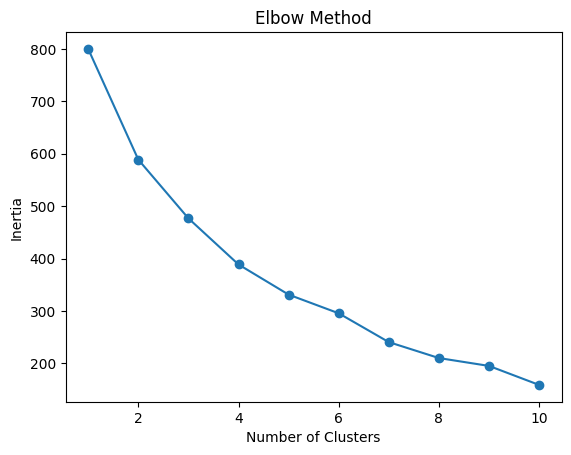

In [9]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


In [10]:
kmeans = KMeans(n_clusters=5, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_kmeans


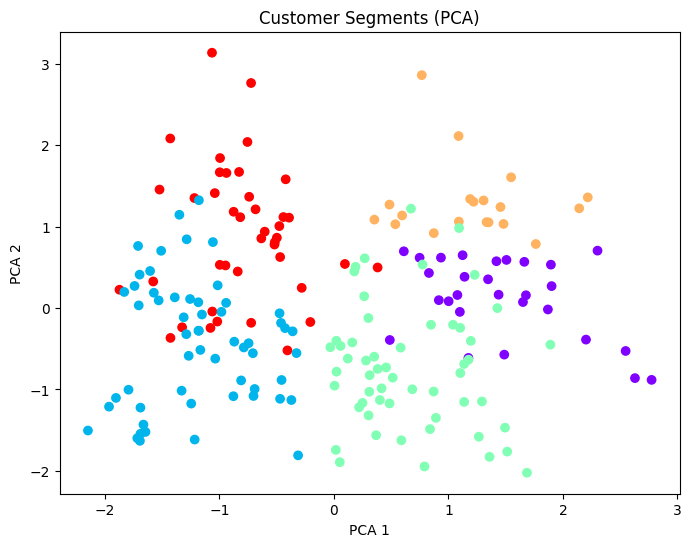

In [11]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_features[:, 0], pca_features[:, 1], c=y_kmeans, cmap='rainbow')
plt.title("Customer Segments (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [12]:
cluster_summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(cluster_summary)


               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        57.214286           46.785714               38.714286
1        28.438596           59.666667               67.684211
2        48.109091           58.818182               34.781818
3        38.473684           85.894737               14.210526
4        28.536585           61.804878               71.097561


In [13]:
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score


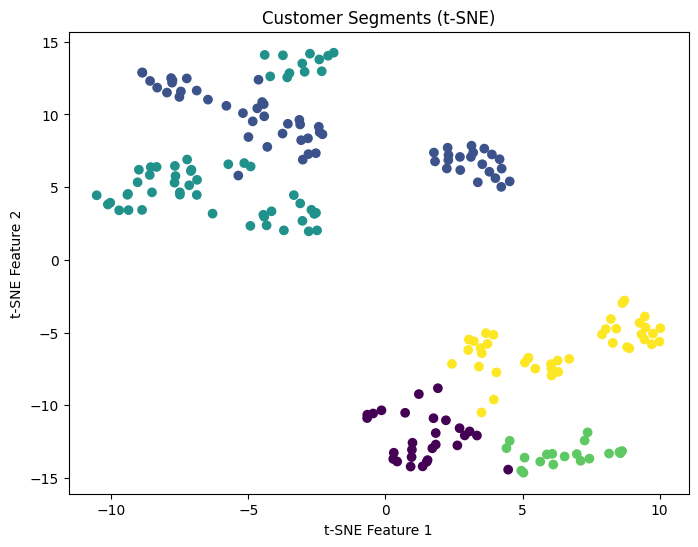

In [14]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=0)
tsne_results = tsne.fit_transform(X_scaled)

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_kmeans, cmap='viridis')
plt.title("Customer Segments (t-SNE)")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.show()


In [15]:
score = silhouette_score(X_scaled, y_kmeans)
print(f"Silhouette Score for K={kmeans.n_clusters}:", round(score, 3))


Silhouette Score for K=5: 0.318


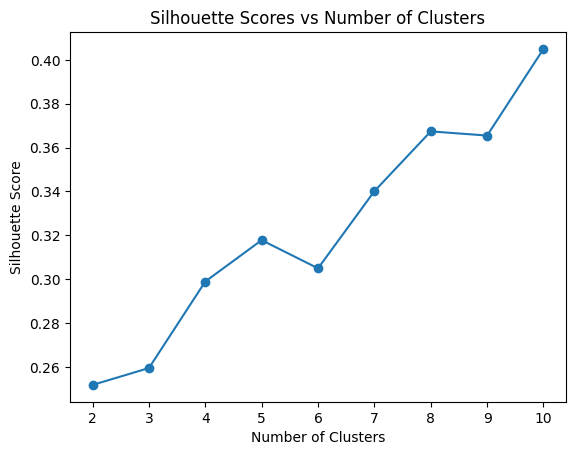

In [16]:
from sklearn.metrics import silhouette_score

scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0)
    y = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, y)
    scores.append(score)

plt.plot(K_range, scores, marker='o')
plt.title("Silhouette Scores vs Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()


In [17]:
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=0)
    y = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, y)
    print(f"K={k}, Silhouette Score={score:.3f}")


K=2, Silhouette Score=0.252
K=3, Silhouette Score=0.260
K=4, Silhouette Score=0.299
K=5, Silhouette Score=0.318
K=6, Silhouette Score=0.305
K=7, Silhouette Score=0.340
K=8, Silhouette Score=0.367
K=9, Silhouette Score=0.365
K=10, Silhouette Score=0.405


In [18]:
kmeans = KMeans(n_clusters=10, random_state=0)
y_kmeans = kmeans.fit_predict(X_scaled)
df['Cluster'] = y_kmeans


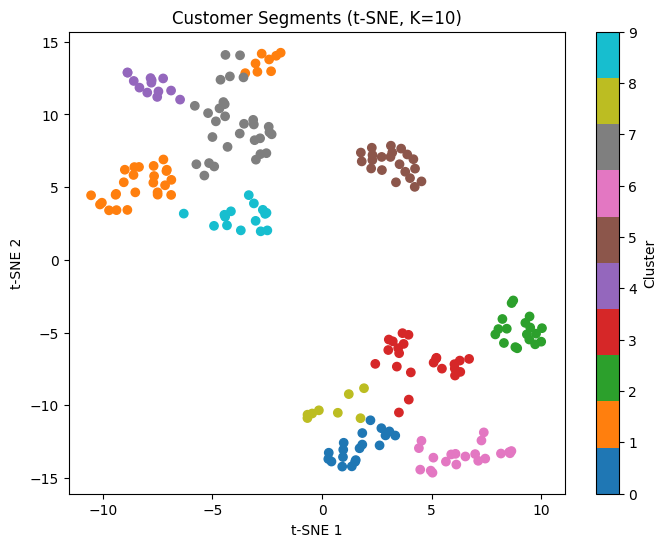

In [19]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=0)
tsne_results = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=y_kmeans, cmap='tab10')
plt.title("Customer Segments (t-SNE, K=10)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.colorbar(label="Cluster")
plt.show()


In [20]:
df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,59.315789,54.315789,49.210526
1,52.575758,47.484848,42.242424
2,33.277778,87.111111,82.666667
3,24.826087,42.000000,62.043478
4,25.461538,25.692308,80.538462
5,32.190476,86.047619,81.666667
6,39.500000,85.150000,14.050000
7,28.533333,51.433333,43.033333
8,52.000000,25.875000,17.250000


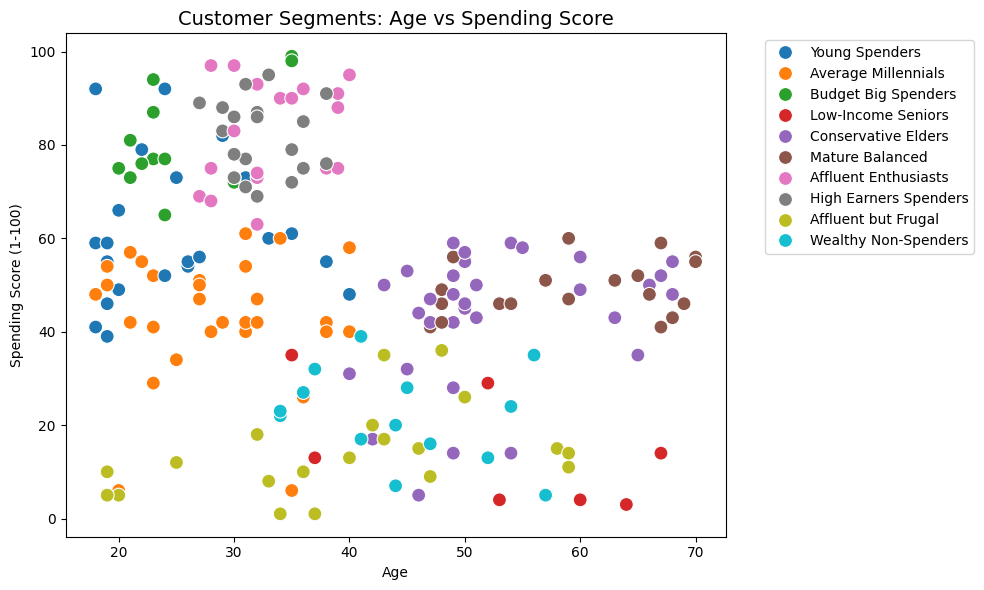

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assign readable labels (optional)
segment_labels = {
    0: "Mature Balanced",
    1: "Conservative Elders",
    2: "Affluent Enthusiasts",
    3: "Young Spenders",
    4: "Budget Big Spenders",
    5: "High Earners Spenders",
    6: "Affluent but Frugal",
    7: "Average Millennials",
    8: "Low-Income Seniors",
    9: "Wealthy Non-Spenders"
}
df['Segment'] = df['Cluster'].map(segment_labels)

# Plot: Age vs Spending Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)', hue='Segment', palette='tab10', s=100)
plt.title("Customer Segments: Age vs Spending Score", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [22]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Age',
    y='Spending Score (1-100)',
    color='Segment',
    size='Annual Income (k$)',
    hover_data=['CustomerID', 'Annual Income (k$)', 'Segment'],
    title="Interactive Customer Segmentation"
)
fig.show()


In [23]:
fig.write_html("customer_segments.html")  # For Plotly
plt.savefig("seaborn_segment_plot.png", dpi=300)  # For Seaborn


<Figure size 640x480 with 0 Axes>